# Week 4 — Hidden Markov Models and Sequential Data
**Course:** 21CSC305P Machine Learning · **Unit 4 – Hidden Markov Models**

**Topics covered:** sequential data · Markov models · HMM · maximum likelihood for the HMM (Baum–Welch / EM) ·
forward and backward algorithms · sum-product algorithm · scaling factors · Viterbi algorithm · linear dynamical systems.

**Practice task**
1. Implement an HMM to predict sequential data

Everything (forward/backward with scaling, Baum–Welch, Viterbi, prediction, Kalman filter) is implemented from scratch with NumPy
and validated with brute-force checks.

In [1]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from itertools import product, permutations
from scipy.special import logsumexp
from scipy.stats import norm

np.random.seed(0)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100
PAL = sns.color_palette("tab10")

## Part A — Theory in code

### A1. Markov models
Sequential data are not i.i.d.: the product rule gives $p(x_1..x_T)=p(x_1)\prod_t p(x_t|x_1..x_{t-1})$. A **first-order Markov chain** assumes
$p(x_t|x_{1:t-1})=p(x_t|x_{t-1})$, parameterised by an initial distribution $\boldsymbol\pi$ and a transition matrix $A_{ij}=p(x_t=j|x_{t-1}=i)$.
The ML estimate of $A$ is just normalised transition counts, and (for an ergodic chain) $\boldsymbol\pi A^n\to$ the **stationary distribution**
(the left eigenvector of $A$ with eigenvalue 1).

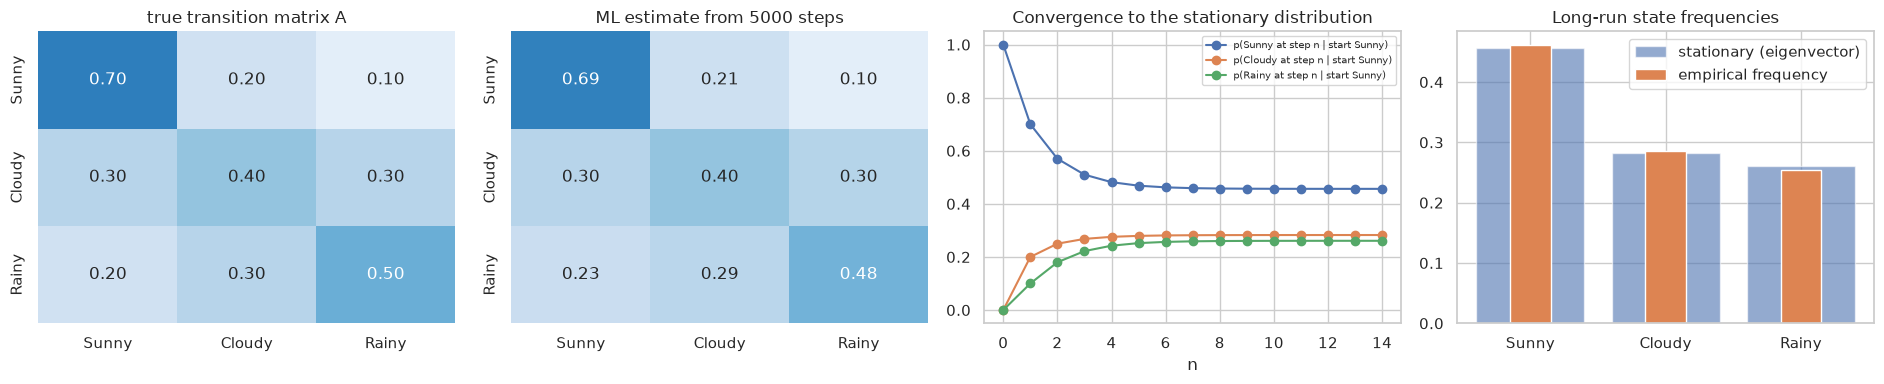

stationary distribution: {'Sunny': np.float64(0.457), 'Cloudy': np.float64(0.283), 'Rainy': np.float64(0.261)}


In [2]:
states = ["Sunny", "Cloudy", "Rainy"]
A_true = np.array([[0.7, 0.2, 0.1],
                   [0.3, 0.4, 0.3],
                   [0.2, 0.3, 0.5]])

def simulate_chain(A, T, seed=0, s0=0):
    r = np.random.default_rng(seed); s = [s0]
    for _ in range(T - 1): s.append(r.choice(len(A), p=A[s[-1]]))
    return np.array(s)

seq = simulate_chain(A_true, 5000)
counts = np.zeros((3, 3))
for a, b in zip(seq[:-1], seq[1:]): counts[a, b] += 1
A_hat = counts / counts.sum(1, keepdims=True)                         # maximum likelihood estimate

# stationary distribution: left eigenvector for eigenvalue 1
w, v = np.linalg.eig(A_true.T); stat = np.real(v[:, np.argmin(abs(w - 1))]); stat /= stat.sum()

fig, ax = plt.subplots(1, 4, figsize=(19, 4))
for a_, M, ttl in [(ax[0], A_true, "true transition matrix A"), (ax[1], A_hat, "ML estimate from 5000 steps")]:
    sns.heatmap(M, annot=True, fmt=".2f", cmap="Blues", vmin=0, vmax=1, xticklabels=states, yticklabels=states, cbar=False, ax=a_); a_.set_title(ttl)
for i in range(3): ax[2].plot([np.linalg.matrix_power(A_true, k)[0, i] for k in range(15)], "o-", label=f"p({states[i]} at step n | start Sunny)")
ax[2].set(xlabel="n", title="Convergence to the stationary distribution"); ax[2].legend(fontsize=7)
ax[3].bar(states, stat, alpha=.6, label="stationary (eigenvector)"); ax[3].bar(states, np.bincount(seq) / len(seq), width=.3, label="empirical frequency"); ax[3].legend(); ax[3].set_title("Long-run state frequencies")
plt.tight_layout(); plt.show()
print("stationary distribution:", dict(zip(states, stat.round(3))))

### A2. Hidden Markov model
Latent states $z_t\in\{1..K\}$ follow a Markov chain; each emits an observation $x_t$ from $p(x_t|z_t)$:

$$p(X,Z|\theta)=p(z_1|\pi)\prod_{t=2}^T A_{z_{t-1}z_t}\prod_{t=1}^T p(x_t|z_t) .$$

Three classic problems: **evaluation** $p(X|\theta)$ (forward algorithm), **decoding** $\arg\max_Z p(Z|X)$ (Viterbi), **learning** $\theta$ (Baum–Welch = EM).

* **Forward** $\alpha_t(k)=p(x_{1:t},z_t=k)=\big[\sum_j\alpha_{t-1}(j)A_{jk}\big]p(x_t|k)$
* **Backward** $\beta_t(k)=p(x_{t+1:T}|z_t=k)=\sum_j A_{kj}p(x_{t+1}|j)\beta_{t+1}(j)$
* **Scaling.** $\alpha$ shrinks like $10^{-T}$ and underflows. Use $\hat\alpha_t=\alpha_t/p(x_{1:t})$ with scale factors $c_t=p(x_t|x_{1:t-1})$, so $\ln p(X)=\sum_t\ln c_t$.
* These recursions are the **sum-product algorithm** on the chain-structured factor graph; Viterbi is the **max-sum** version.
* **E-step**: $\gamma_t(k)=p(z_t=k|X)$, $\xi_t(j,k)=p(z_{t-1}=j,z_t=k|X)$. **M-step**: $\pi_k=\gamma_1(k)$, $A_{jk}=\sum_t\xi_t(j,k)/\sum_t\gamma_{t-1}(j)$, and emission parameters from $\gamma$-weighted statistics.

In [3]:
class HMM:
    """Hidden Markov model with discrete or 1-D Gaussian emissions (scaled forward-backward, Baum-Welch, Viterbi)."""

    def __init__(self, n_states, emission="discrete", n_symbols=None, n_iter=200, tol=1e-6, seed=0):
        self.K, self.emission, self.V, self.n_iter, self.tol, self.seed = n_states, emission, n_symbols, n_iter, tol, seed

    # ---------- parameters ----------
    def init_params(self, seqs, rng):
        K = self.K
        self.pi_ = rng.dirichlet(np.ones(K) * 5)
        self.A_ = rng.dirichlet(np.ones(K) * 5, size=K)
        if self.emission == "discrete":
            self.B_ = rng.dirichlet(np.ones(self.V), size=K)
        else:
            allx = np.concatenate(seqs); qs = np.quantile(allx, (np.arange(K) + .5) / K)
            self.mu_ = qs + rng.normal(0, allx.std() * .1, K); self.var_ = np.full(K, allx.var()) * rng.uniform(.5, 1.5, K)

    def log_emission(self, x):                       # (T, K) matrix of ln p(x_t | z_t = k)
        if self.emission == "discrete": return np.log(self.B_[:, x].T + 1e-300)
        return norm.logpdf(np.asarray(x)[:, None], self.mu_[None], np.sqrt(self.var_)[None])

    # ---------- inference ----------
    def forward_backward(self, x):
        T, K = len(x), self.K
        logB = self.log_emission(x); m = logB.max(1, keepdims=True); B = np.exp(logB - m)    # row-shifted for numerical safety
        alpha, c = np.zeros((T, K)), np.zeros(T)
        a = self.pi_ * B[0]; c[0] = a.sum(); alpha[0] = a / c[0]
        for t in range(1, T):
            a = (alpha[t - 1] @ self.A_) * B[t]; c[t] = a.sum(); alpha[t] = a / c[t]
        beta = np.ones((T, K))
        for t in range(T - 2, -1, -1):
            beta[t] = self.A_ @ (B[t + 1] * beta[t + 1]) / c[t + 1]
        loglik = np.log(c).sum() + m.sum()
        gamma = alpha * beta
        xi = (alpha[:-1, :, None] * self.A_[None] * (B[1:] * beta[1:])[:, None, :]) / c[1:, None, None]
        return alpha, beta, gamma, xi, loglik

    def score(self, x): return self.forward_backward(x)[-1]

    def viterbi(self, x):
        T, K = len(x), self.K
        logA, logB = np.log(self.A_ + 1e-300), self.log_emission(x)
        delta = np.zeros((T, K)); psi = np.zeros((T, K), int)
        delta[0] = np.log(self.pi_ + 1e-300) + logB[0]
        for t in range(1, T):
            cand = delta[t - 1][:, None] + logA; psi[t] = cand.argmax(0); delta[t] = cand.max(0) + logB[t]
        path = np.zeros(T, int); path[-1] = delta[-1].argmax()
        for t in range(T - 2, -1, -1): path[t] = psi[t + 1, path[t + 1]]
        return path, delta[-1].max()

    # ---------- learning (Baum-Welch) ----------
    def _fit_once(self, seqs, seed):
        rng = np.random.default_rng(seed); self.init_params(seqs, rng); hist = []
        for _ in range(self.n_iter):
            pi_acc, xi_acc, g_prev_acc = np.zeros(self.K), np.zeros((self.K, self.K)), np.zeros(self.K)
            if self.emission == "discrete": B_num = np.zeros((self.K, self.V))
            else: w_acc, wx_acc = np.zeros(self.K), np.zeros(self.K)
            ll = 0
            for x in seqs:
                _, _, g, xi, l = self.forward_backward(x); ll += l
                pi_acc += g[0]; xi_acc += xi.sum(0)
                if self.emission == "discrete":
                    for v in range(self.V): B_num[:, v] += g[np.asarray(x) == v].sum(0)
                else:
                    w_acc += g.sum(0); wx_acc += g.T @ np.asarray(x)
            hist.append(ll)
            self.pi_ = pi_acc / pi_acc.sum(); self.A_ = xi_acc / xi_acc.sum(1, keepdims=True)
            if self.emission == "discrete": self.B_ = (B_num + 1e-12) / (B_num + 1e-12).sum(1, keepdims=True)
            else:
                self.mu_ = wx_acc / w_acc
                self.var_ = np.maximum(sum(((np.asarray(x)[:, None] - self.mu_) ** 2 * self.forward_backward(x)[2]).sum(0) for x in seqs) / w_acc, 1e-6)
            if len(hist) > 1 and abs(hist[-1] - hist[-2]) < self.tol: break
        return hist[-1], hist

    def fit(self, seqs, n_restarts=5):
        seqs = [seqs] if np.ndim(seqs[0]) == 0 else seqs
        best = None
        for r in range(n_restarts):
            ll, hist = self._fit_once(seqs, self.seed + r)
            if best is None or ll > best[0]: best = (ll, hist, self.get_params())
        self.set_params(best[2]); self.loglik_, self.history_ = best[0], best[1]
        self.n_obs_ = sum(len(x) for x in seqs); return self

    def get_params(self): return {k: getattr(self, k).copy() for k in ["pi_", "A_", "B_", "mu_", "var_"] if hasattr(self, k)}
    def set_params(self, d): [setattr(self, k, v.copy()) for k, v in d.items()]
    def n_params(self): return (self.K - 1) + self.K * (self.K - 1) + (self.K * (self.V - 1) if self.emission == "discrete" else 2 * self.K)
    def bic(self): return -2 * self.loglik_ + self.n_params() * np.log(self.n_obs_)

    # ---------- prediction ----------
    def predictive(self, x):
        """p(x_{t+1} | x_{1:t}) for every t (discrete: (T,V) probabilities; gaussian: mixture weights (T,K))."""
        alpha = self.forward_backward(x)[0]; next_state = alpha @ self.A_
        return next_state @ self.B_ if self.emission == "discrete" else next_state

    def sample(self, T, seed=0):
        r = np.random.default_rng(seed); z = np.zeros(T, int); z[0] = r.choice(self.K, p=self.pi_)
        for t in range(1, T): z[t] = r.choice(self.K, p=self.A_[z[t - 1]])
        if self.emission == "discrete": x = np.array([r.choice(self.V, p=self.B_[k]) for k in z])
        else: x = r.normal(self.mu_[z], np.sqrt(self.var_[z]))
        return x, z

def set_hmm(model, pi, A, B=None, mu=None, var=None):
    model.pi_, model.A_ = np.array(pi, float), np.array(A, float)
    if B is not None: model.B_ = np.array(B, float)
    if mu is not None: model.mu_, model.var_ = np.array(mu, float), np.array(var, float)
    return model

### A3. Validating the algorithms
1. **Forward algorithm vs. brute force.** For a short sequence enumerate all $K^T$ state paths and sum the joint probability.
2. **Viterbi vs. brute force.** The best path must equal the arg-max over all paths.
3. **Why scaling matters.** The un-scaled forward variable underflows to 0 for long sequences; the scaled one doesn't.

likelihood   brute force = 0.0011220940   forward algorithm = 0.0011220940
best path    brute force = (1, 0, 0, 0, 1, 1)   Viterbi = (1, 0, 0, 0, 1, 1)   (log-prob -8.788939 vs -8.788939)
posterior p(z_3=0 | X): brute force = 0.895480   forward-backward = 0.895480


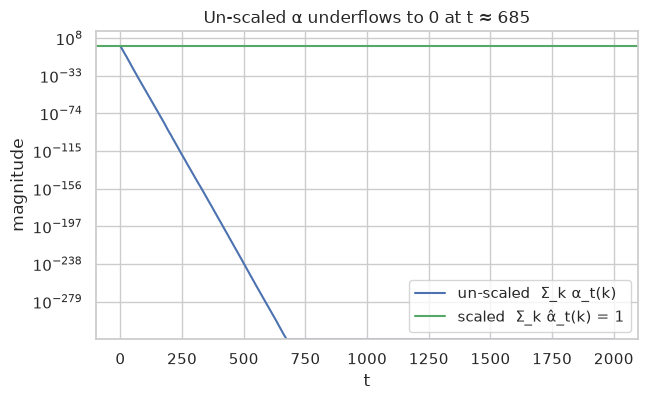

scaled log-likelihood of the 2000-step sequence: -2189.31


In [4]:
toy = set_hmm(HMM(2, "discrete", 3), pi=[.6, .4], A=[[.7, .3], [.4, .6]], B=[[.1, .4, .5], [.6, .3, .1]])
obs = np.array([0, 1, 2, 2, 0, 1])

# brute force enumeration of all 2^6 paths
joint = {}
for path in product(range(2), repeat=len(obs)):
    p = toy.pi_[path[0]] * toy.B_[path[0], obs[0]]
    for t in range(1, len(obs)): p *= toy.A_[path[t - 1], path[t]] * toy.B_[path[t], obs[t]]
    joint[path] = p
bf_lik = sum(joint.values()); bf_path = max(joint, key=joint.get)
vpath, vlog = toy.viterbi(obs)
print(f"likelihood   brute force = {bf_lik:.10f}   forward algorithm = {np.exp(toy.score(obs)):.10f}")
print(f"best path    brute force = {bf_path}   Viterbi = {tuple(int(v) for v in vpath)}   (log-prob {np.log(joint[bf_path]):.6f} vs {vlog:.6f})")
_, _, gamma, xi, _ = toy.forward_backward(obs)
bf_gamma0 = sum(p for path, p in joint.items() if path[2] == 0) / bf_lik
print(f"posterior p(z_3=0 | X): brute force = {bf_gamma0:.6f}   forward-backward = {gamma[2, 0]:.6f}")

# underflow of the un-scaled forward recursion
long_obs, _ = toy.sample(2000, seed=1); a = toy.pi_ * toy.B_[:, long_obs[0]]; mags = [a.sum()]
for x in long_obs[1:]: a = (a @ toy.A_) * toy.B_[:, x]; mags.append(a.sum())
mags = np.array(mags); first_zero = int(np.argmax(mags == 0))
plt.figure(figsize=(7, 4)); plt.semilogy(np.maximum(mags, 1e-320), label="un-scaled  Σ_k α_t(k)")
plt.axhline(1, c="g", label="scaled  Σ_k α̂_t(k) = 1"); plt.xlabel("t"); plt.ylabel("magnitude"); plt.legend(); plt.title(f"Un-scaled α underflows to 0 at t ≈ {first_zero}"); plt.show()
print(f"scaled log-likelihood of the 2000-step sequence: {toy.score(long_obs):.2f}")

## Practice 1 — Implement an HMM to predict sequential data

### Problem 1: Weather (hidden) → activity (observed)
Classic setup: the weather is hidden (*Rainy*, *Sunny*) and we only see what a person does each day (*walk*, *shop*, *clean*).
Tasks: (i) **decode** the hidden weather (Viterbi, posterior), (ii) **learn** the HMM from observations only (Baum–Welch),
(iii) **predict** the next activity, (iv) choose the number of hidden states.

first 15 days  hidden : ['S', 'S', 'S', 'R', 'R', 'R', 'R', 'R', 'R', 'S', 'S', 'S', 'S', 'S', 'S']
               observed: ['walk', 'walk', 'walk', 'clean', 'clean', 'shop', 'walk', 'clean', 'clean', 'walk', 'walk', 'walk', 'walk', 'shop', 'walk']


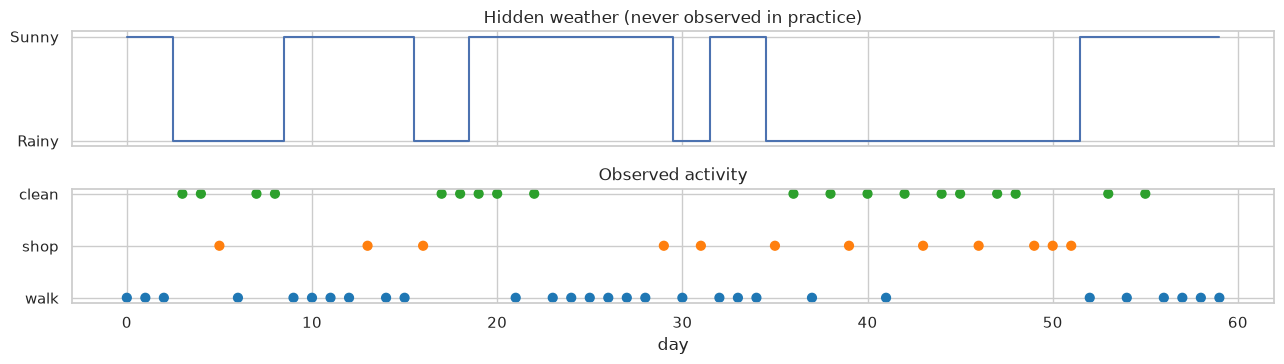

In [5]:
S_NAMES, O_NAMES = ["Rainy", "Sunny"], ["walk", "shop", "clean"]
true = set_hmm(HMM(2, "discrete", 3), pi=[.5, .5], A=[[.85, .15], [.20, .80]], B=[[.1, .3, .6], [.7, .2, .1]])

x_train, z_train = true.sample(3000, seed=10)
x_test,  z_test  = true.sample(600,  seed=11)
print("first 15 days  hidden :", [S_NAMES[s][0] for s in z_train[:15]])
print("               observed:", [O_NAMES[o] for o in x_train[:15]])

fig, ax = plt.subplots(2, 1, figsize=(13, 3.8), sharex=True)
ax[0].step(range(60), z_train[:60], where="mid"); ax[0].set_yticks([0, 1], S_NAMES); ax[0].set_title("Hidden weather (never observed in practice)")
ax[1].scatter(range(60), x_train[:60], c=[PAL[o] for o in x_train[:60]], s=40); ax[1].set_yticks([0, 1, 2], O_NAMES); ax[1].set_title("Observed activity"); ax[1].set_xlabel("day")
plt.tight_layout(); plt.show()

#### (i) Learn the model with Baum–Welch (EM) using observations only

final log-likelihood: learned -3125.06    true parameters -3128.15


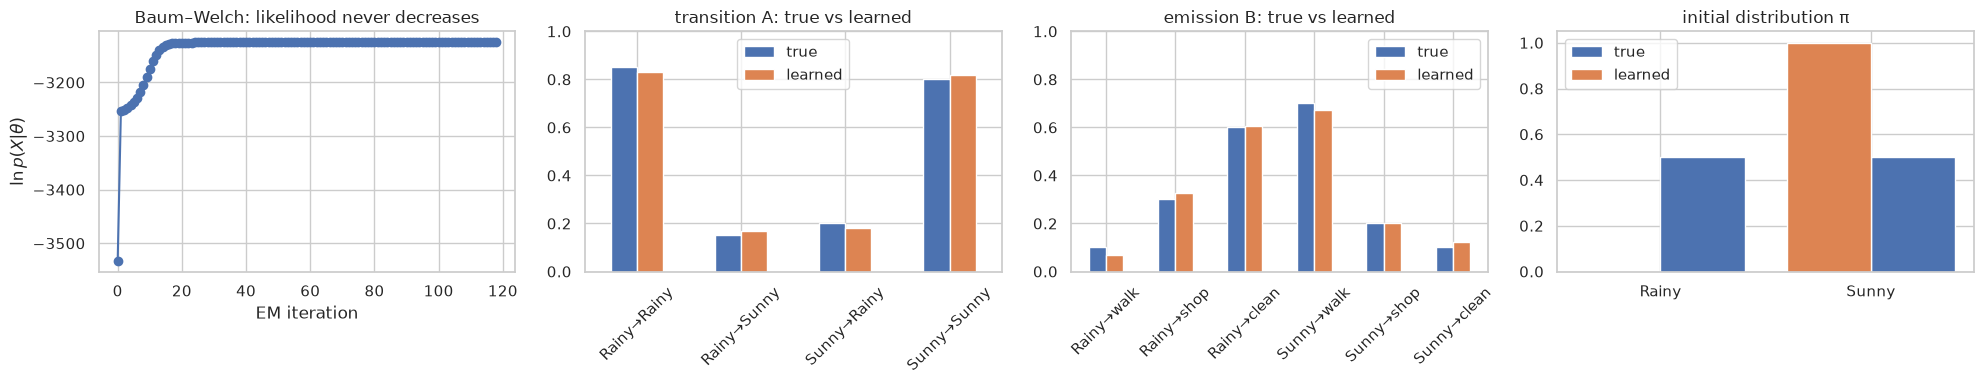

           Rainy→Rainy  Rainy→Sunny  Sunny→Rainy  Sunny→Sunny
true A            0.85         0.15        0.200        0.800
learned A         0.83         0.17        0.183        0.817


In [6]:
model = HMM(2, "discrete", 3, seed=0).fit(x_train, n_restarts=8)

def align(model, ref):                                   # fix label switching: reorder learned states to best match the reference
    best = min(permutations(range(model.K)), key=lambda p: np.abs(model.B_[list(p)] - ref.B_).sum())
    p = list(best); model.pi_, model.A_, model.B_ = model.pi_[p], model.A_[np.ix_(p, p)], model.B_[p]; return p
align(model, true)

print(f"final log-likelihood: learned {model.loglik_:.2f}    true parameters {true.score(x_train):.2f}")
fig, ax = plt.subplots(1, 4, figsize=(20, 4))
ax[0].plot(model.history_, "o-"); ax[0].set(xlabel="EM iteration", ylabel=r"$\ln p(X|\theta)$", title="Baum–Welch: likelihood never decreases")
for a_, M_t, M_l, ttl, xt, yt in [(ax[1], true.A_, model.A_, "transition A", S_NAMES, S_NAMES), (ax[2], true.B_, model.B_, "emission B", O_NAMES, S_NAMES)]:
    d = pd.DataFrame(np.c_[M_t.ravel(), M_l.ravel()], columns=["true", "learned"], index=[f"{i}→{j}" for i in yt for j in xt]); d.plot.bar(ax=a_, rot=45); a_.set_title(f"{ttl}: true vs learned"); a_.set_ylim(0, 1)
ax[3].bar(S_NAMES, true.pi_, width=.4, align="edge", label="true"); ax[3].bar(S_NAMES, model.pi_, width=-.4, align="edge", label="learned"); ax[3].legend(); ax[3].set_title("initial distribution π")
plt.tight_layout(); plt.show()
print(pd.DataFrame({"true A": true.A_.ravel(), "learned A": model.A_.ravel()}, index=[f"{i}→{j}" for i in S_NAMES for j in S_NAMES]).round(3).T.to_string())
assert np.all(np.diff(model.history_) > -1e-6), "EM must not decrease the likelihood"

#### (ii) Decode the hidden weather: Viterbi (single best path) vs. posterior marginals

state accuracy  Viterbi (learned model): 0.848    posterior-marginal: 0.853    true-parameter Viterbi: 0.855    majority baseline: 0.592


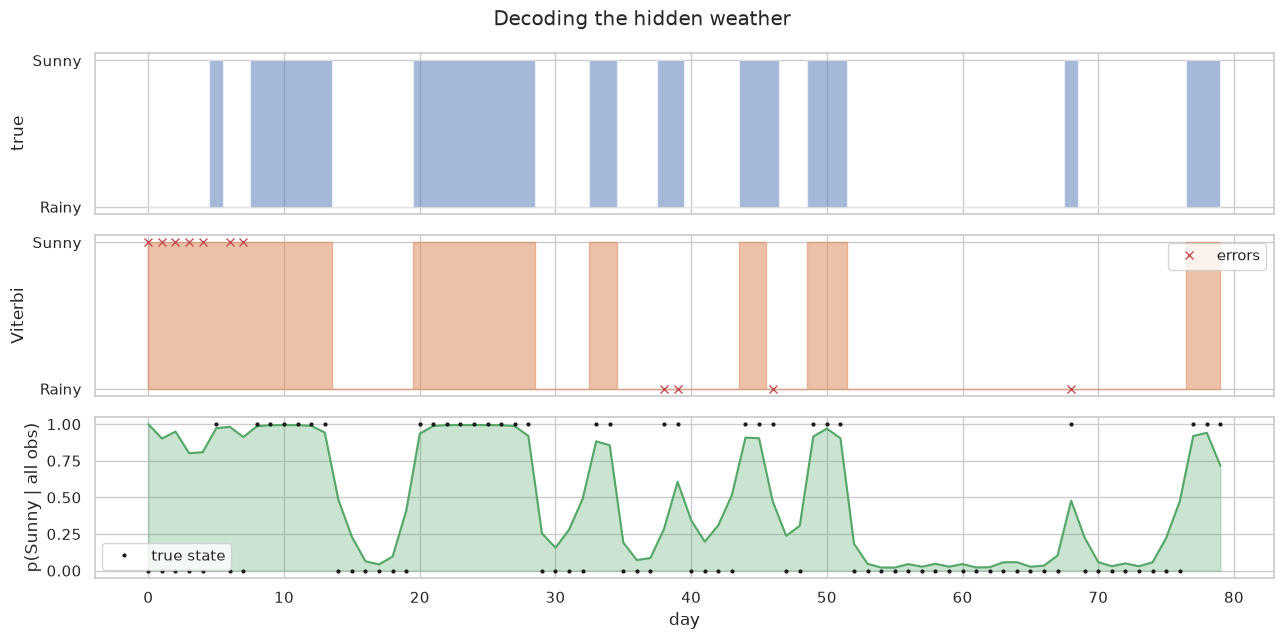

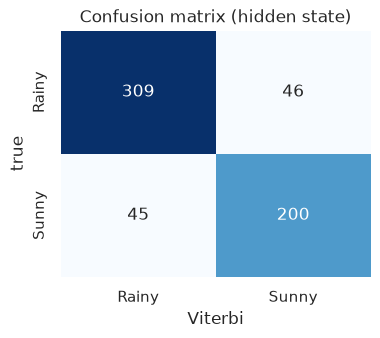

In [7]:
path, _ = model.viterbi(x_test)
post = model.forward_backward(x_test)[2]; marg = post.argmax(1)
print(f"state accuracy  Viterbi (learned model): {np.mean(path == z_test):.3f}    posterior-marginal: {np.mean(marg == z_test):.3f}    true-parameter Viterbi: {np.mean(true.viterbi(x_test)[0] == z_test):.3f}    majority baseline: {max(np.mean(z_test == 0), np.mean(z_test == 1)):.3f}")

w = slice(0, 80)
fig, ax = plt.subplots(3, 1, figsize=(13, 6.5), sharex=True)
ax[0].fill_between(range(80), z_test[w], step="mid", alpha=.5); ax[0].set_ylabel("true"); ax[0].set_yticks([0, 1], S_NAMES)
ax[1].fill_between(range(80), path[w], step="mid", alpha=.5, color="C1"); ax[1].set_ylabel("Viterbi"); ax[1].set_yticks([0, 1], S_NAMES)
ax[1].plot(np.where(path[w] != z_test[w])[0], path[w][path[w] != z_test[w]], "rx", label="errors"); ax[1].legend(loc="upper right")
ax[2].plot(post[w, 1], c="C2"); ax[2].fill_between(range(80), post[w, 1], alpha=.3, color="C2"); ax[2].plot(z_test[w], "k.", ms=4, label="true state"); ax[2].set(ylabel="p(Sunny | all obs)", xlabel="day"); ax[2].legend()
plt.suptitle("Decoding the hidden weather"); plt.tight_layout(); plt.show()

cm = pd.crosstab(pd.Series(np.array(S_NAMES)[z_test], name="true"), pd.Series(np.array(S_NAMES)[path], name="Viterbi"))
plt.figure(figsize=(4, 3.2)); sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False); plt.title("Confusion matrix (hidden state)"); plt.show()

#### (iii) Predict the next observation
Given the history $x_{1:t}$ the HMM predicts $p(x_{t+1}|x_{1:t})=\sum_j\Big[\sum_i\hat\alpha_t(i)A_{ij}\Big]B_{j,x_{t+1}}$.
We compare against (a) frequency baseline, (b) a first-order Markov chain **on the observations**, and (c) an oracle HMM with the true parameters (upper bound).

,accuracy,log_loss
frequency,0.3623,1.0953
Markov on observations,0.4658,1.0559
HMM (learned),0.4641,1.0522
"HMM (true params, oracle)",0.4658,1.0527


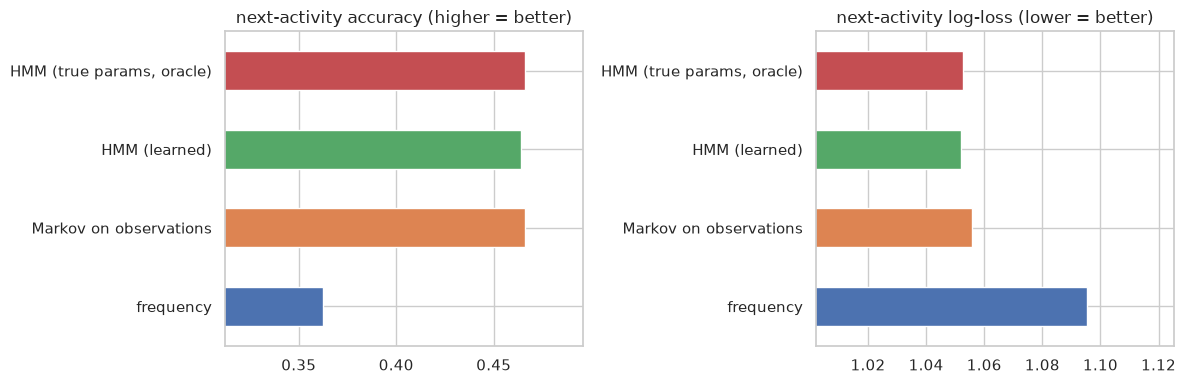

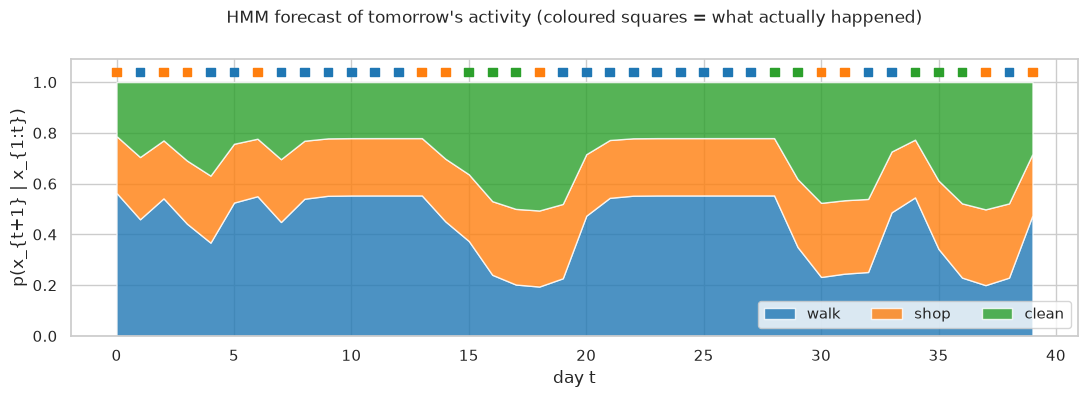

In [8]:
def one_step_eval(P, x):                      # P[t] = predictive distribution for x[t+1]
    P = P[:-1]; y = x[1:]
    return dict(accuracy=np.mean(P.argmax(1) == y), log_loss=-np.mean(np.log(P[np.arange(len(y)), y])))

# baseline (a): global frequency
freq = np.bincount(x_train, minlength=3) / len(x_train); P_freq = np.tile(freq, (len(x_test), 1))
# baseline (b): first-order Markov on observations
C = np.ones((3, 3)) * 1e-3
for a, b in zip(x_train[:-1], x_train[1:]): C[a, b] += 1
T1 = C / C.sum(1, keepdims=True); P_mk = T1[x_test]

results = pd.DataFrame({"frequency": one_step_eval(P_freq, x_test), "Markov on observations": one_step_eval(P_mk, x_test),
                        "HMM (learned)": one_step_eval(model.predictive(x_test), x_test), "HMM (true params, oracle)": one_step_eval(true.predictive(x_test), x_test)}).T
display(results.round(4))

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
results["accuracy"].plot.barh(ax=ax[0], color=sns.color_palette()[:4]); ax[0].set_xlim(results["accuracy"].min() - .05, results["accuracy"].max() + .03); ax[0].set_title("next-activity accuracy (higher = better)")
results["log_loss"].plot.barh(ax=ax[1], color=sns.color_palette()[:4]); ax[1].set_xlim(results["log_loss"].min() - .05, results["log_loss"].max() + .03); ax[1].set_title("next-activity log-loss (lower = better)")
plt.tight_layout(); plt.show()

# predicted distribution over the next activity for a few days
Pn = model.predictive(x_test)[:40]
plt.figure(figsize=(13, 3.6)); plt.stackplot(range(40), Pn.T, labels=O_NAMES, colors=PAL[:3], alpha=.8); plt.scatter(np.arange(40) , np.ones(40) * 1.04, c=[PAL[o] for o in x_test[1:41]], marker="s", s=40, clip_on=False)
plt.legend(ncol=3, loc="lower right"); plt.xlabel("day t"); plt.ylabel("p(x_{t+1} | x_{1:t})"); plt.title("HMM forecast of tomorrow's activity (coloured squares = what actually happened)", y=1.1); plt.show()

**Reading the results.** The learned HMM reaches the oracle's accuracy and log-loss, and clearly beats the frequency baseline. A first-order Markov chain on the *observations* is almost as good here:
with persistent hidden states, yesterday's activity already carries most of the information about today's weather. The HMM's advantage is that it can integrate evidence from the *whole* history (see how the forecast
above moves smoothly rather than jumping with each observation) and that it also yields the hidden-state interpretation; the gap grows when the hidden dynamics are slower or the emissions are noisier.

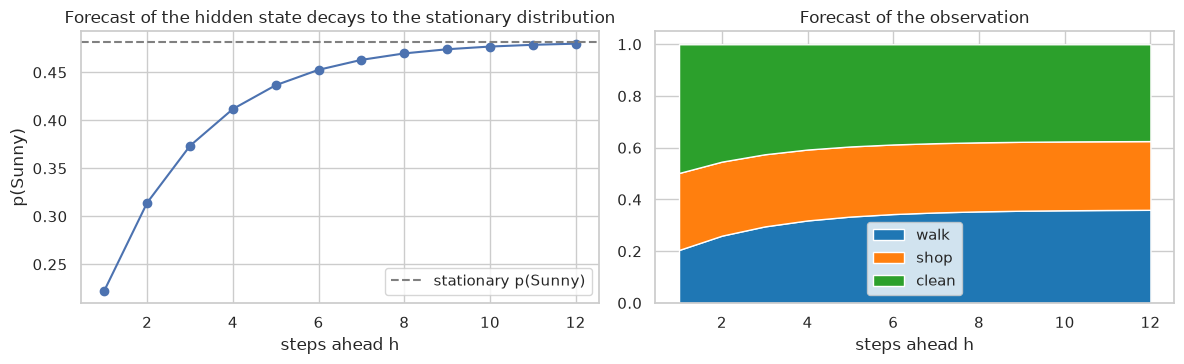

In [9]:
# multi-step ahead forecast: propagate the filtered state through A, h steps
alpha_T = model.forward_backward(x_test)[0][-1]
H = 12; state_dist = [alpha_T @ np.linalg.matrix_power(model.A_, h) for h in range(1, H + 1)]
obs_dist = np.array([s @ model.B_ for s in state_dist])
fig, ax = plt.subplots(1, 2, figsize=(12, 3.8))
w_, v_ = np.linalg.eig(model.A_.T); stat_ = np.abs(np.real(v_[:, np.argmin(abs(w_ - 1))])); stat_ /= stat_.sum()
ax[0].plot(range(1, H + 1), np.array(state_dist)[:, 1], "o-"); ax[0].axhline(stat_[1], c="gray", ls="--", label="stationary p(Sunny)")
ax[0].set(xlabel="steps ahead h", ylabel="p(Sunny)", title="Forecast of the hidden state decays to the stationary distribution"); ax[0].legend()
ax[1].stackplot(range(1, H + 1), obs_dist.T, labels=O_NAMES, colors=PAL[:3]); ax[1].set(xlabel="steps ahead h", title="Forecast of the observation"); ax[1].legend(); plt.tight_layout(); plt.show()

#### (iv) How many hidden states? Held-out likelihood and BIC

,train_loglik,test_loglik,BIC
K,,,
1,-3263.1,-657.1,6542.3
2,-3125.1,-632.3,6306.2
3,-3122.6,-630.6,6357.2
4,-3118.2,-630.5,6420.5
5,-3116.5,-630.5,6505.2


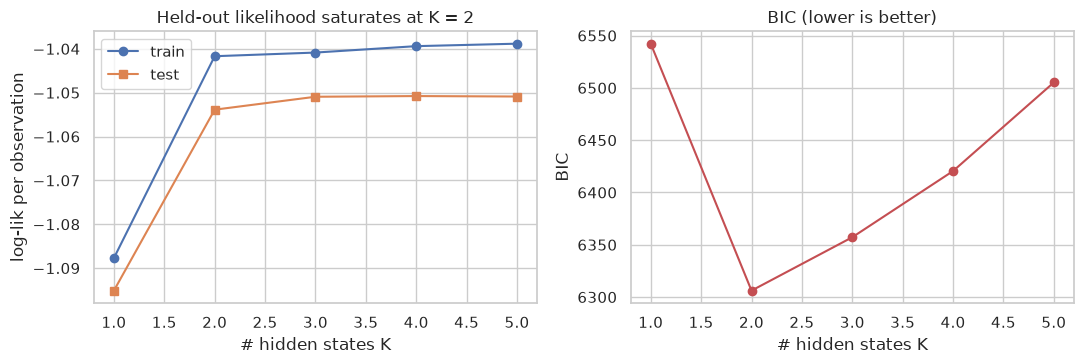

BIC selects K = 2


In [10]:
rows = []
for K in range(1, 6):
    m = HMM(K, "discrete", 3, seed=0).fit(x_train, n_restarts=6)
    rows.append(dict(K=K, train_loglik=m.loglik_, test_loglik=m.score(x_test), BIC=m.bic()))
sel = pd.DataFrame(rows).set_index("K"); display(sel.round(1))
fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
ax[0].plot(sel.index, sel["train_loglik"] / len(x_train), "o-", label="train"); ax[0].plot(sel.index, sel["test_loglik"] / 600, "s-", label="test"); ax[0].legend(); ax[0].set(xlabel="# hidden states K", ylabel="log-lik per observation", title="Held-out likelihood saturates at K = 2")
ax[1].plot(sel.index, sel["BIC"], "o-r"); ax[1].set(xlabel="# hidden states K", ylabel="BIC", title="BIC (lower is better)"); plt.tight_layout(); plt.show()
print("BIC selects K =", sel["BIC"].idxmin())

### Problem 2: Regime detection in a continuous time series (Gaussian-emission HMM)
Financial-style series often switch between a *calm* and a *volatile* regime. We simulate such a series, fit a 2-state Gaussian HMM, recover the regimes
and use the model to forecast the **next-step distribution** (a mixture of Gaussians) — in particular the expected volatility.

         mean calm  mean volatile  sd calm  sd volatile  P(stay calm)  P(stay volatile)
true         0.100         -0.150    0.400        1.400         0.970             0.930
learned      0.113         -0.112    0.412        1.438         0.973             0.919
regime accuracy on the held-out part: 0.934


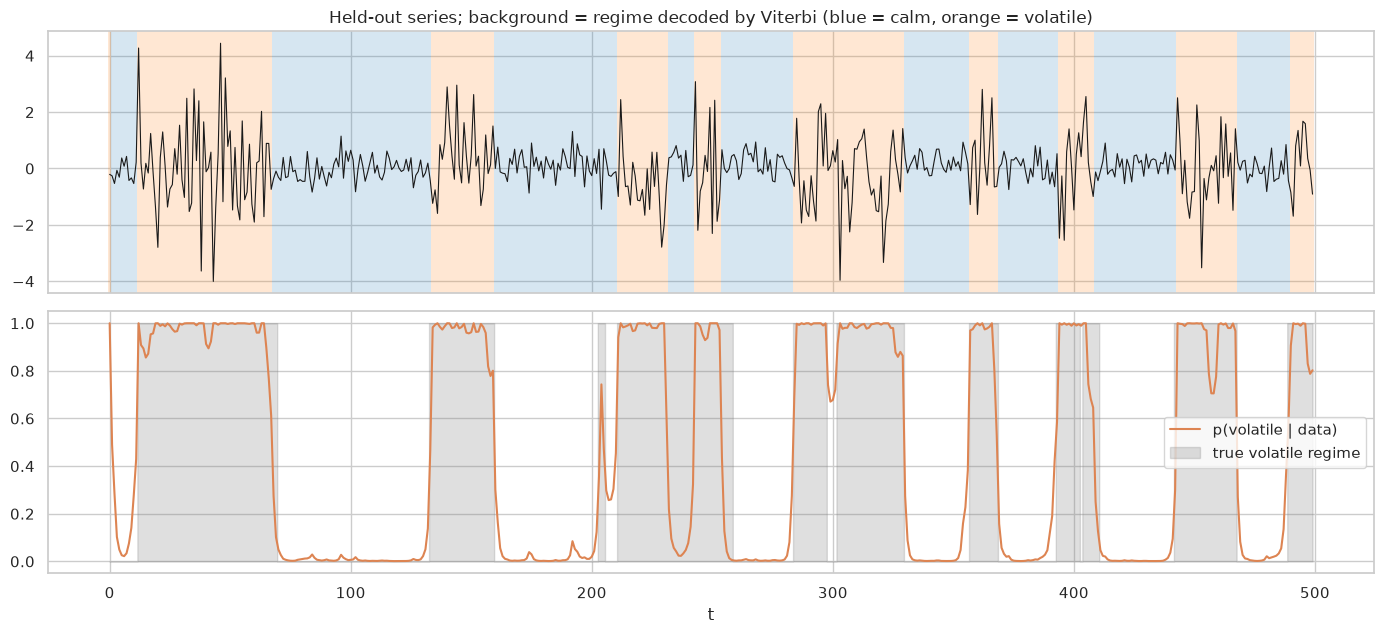

In [11]:
reg = set_hmm(HMM(2, "gaussian"), pi=[.5, .5], A=[[.97, .03], [.07, .93]], mu=[0.10, -0.15], var=[0.4 ** 2, 1.4 ** 2])
y, zr = reg.sample(1500, seed=5)
y_tr, y_te, z_te = y[:1000], y[1000:], zr[1000:]

g = HMM(2, "gaussian", seed=0).fit(y_tr, n_restarts=6)
order = np.argsort(g.var_); g.pi_, g.A_, g.mu_, g.var_ = g.pi_[order], g.A_[np.ix_(order, order)], g.mu_[order], g.var_[order]    # state 0 = calm
print(pd.DataFrame({"true": np.r_[reg.mu_, np.sqrt(reg.var_), reg.A_.diagonal()], "learned": np.r_[g.mu_, np.sqrt(g.var_), g.A_.diagonal()]},
                   index=["mean calm", "mean volatile", "sd calm", "sd volatile", "P(stay calm)", "P(stay volatile)"]).round(3).T.to_string())

path, _ = g.viterbi(y_te); post = g.forward_backward(y_te)[2]
print(f"regime accuracy on the held-out part: {np.mean(path == z_te):.3f}")
fig, ax = plt.subplots(2, 1, figsize=(14, 6.5), sharex=True)
ax[0].plot(y_te, lw=.8, c="k")
for t in range(len(y_te)): ax[0].axvspan(t - .5, t + .5, color=PAL[path[t]], alpha=.18, lw=0)
ax[0].set_title("Held-out series; background = regime decoded by Viterbi (blue = calm, orange = volatile)")
ax[1].plot(post[:, 1], c="C1", label="p(volatile | data)"); ax[1].fill_between(range(len(y_te)), z_te, alpha=.25, step="mid", color="gray", label="true volatile regime"); ax[1].legend(); ax[1].set_xlabel("t")
plt.tight_layout(); plt.show()

mean negative log-predictive-density: constant Gaussian = 1.489   HMM (moment-matched Gaussian) = 1.356   HMM (full mixture) = 1.223


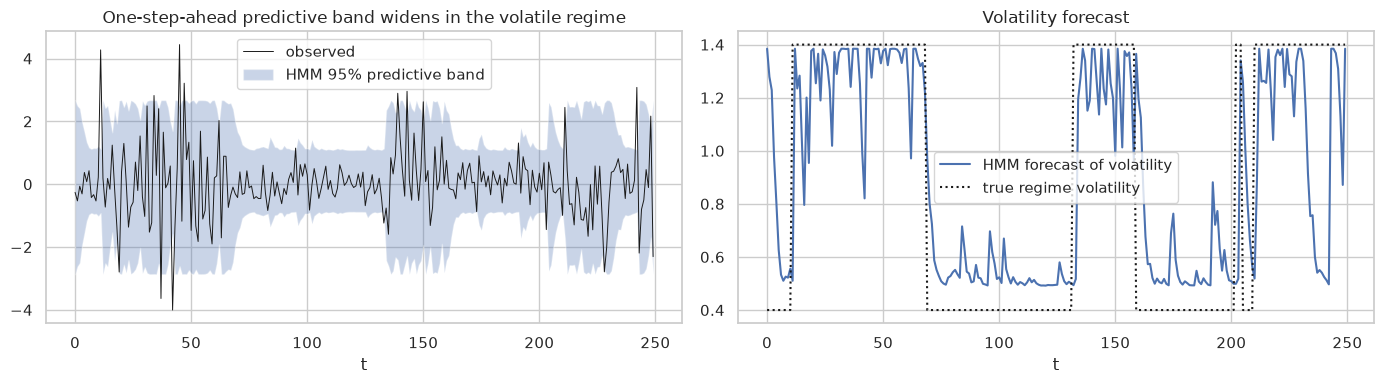

In [12]:
# one-step-ahead forecast: mixture of the per-state Gaussians weighted by the predicted state distribution
w_next = g.predictive(y_te)[:-1]                                  # (T-1, K) mixture weights for y[t+1]
mean_f = w_next @ g.mu_; var_f = w_next @ (g.var_ + g.mu_ ** 2) - mean_f ** 2; sd_f = np.sqrt(var_f)
yt = y_te[1:]
nll_hmm = -np.mean(norm.logpdf(yt, mean_f, sd_f)); nll_const = -np.mean(norm.logpdf(yt, y_tr.mean(), y_tr.std()))
nll_mix = -np.mean(np.log((w_next * norm.pdf(yt[:, None], g.mu_, np.sqrt(g.var_))).sum(1)))
print(f"mean negative log-predictive-density: constant Gaussian = {nll_const:.3f}   HMM (moment-matched Gaussian) = {nll_hmm:.3f}   HMM (full mixture) = {nll_mix:.3f}")

fig, ax = plt.subplots(1, 2, figsize=(14, 4))
ax[0].plot(yt[:250], lw=.7, c="k", label="observed"); ax[0].fill_between(range(250), (mean_f - 2 * sd_f)[:250], (mean_f + 2 * sd_f)[:250], alpha=.3, label="HMM 95% predictive band"); ax[0].legend(); ax[0].set(xlabel="t", title="One-step-ahead predictive band widens in the volatile regime")
true_sd = np.sqrt(reg.var_)[z_te[1:]]; ax[1].plot(sd_f[:250], label="HMM forecast of volatility"); ax[1].plot(true_sd[:250], "k:", label="true regime volatility"); ax[1].legend(); ax[1].set(xlabel="t", title="Volatility forecast")
plt.tight_layout(); plt.show()

## Linear dynamical systems (Kalman filter)
The continuous-latent-state analogue of the HMM: $\mathbf z_t=F\mathbf z_{t-1}+\mathbf w_t$ ($\mathbf w\sim\mathcal N(0,Q)$), $\mathbf x_t=H\mathbf z_t+\mathbf v_t$ ($\mathbf v\sim\mathcal N(0,R)$).
Inference is again forward–backward: the **Kalman filter** (forward, gives $p(\mathbf z_t|x_{1:t})$) and the **Rauch–Tung–Striebel smoother** (backward, gives $p(\mathbf z_t|x_{1:T})$); everything stays Gaussian.
Example: tracking a moving object from noisy position measurements (state = position and velocity).

position RMSE: raw measurements 2.233   Kalman filter 1.085   RTS smoother 0.830


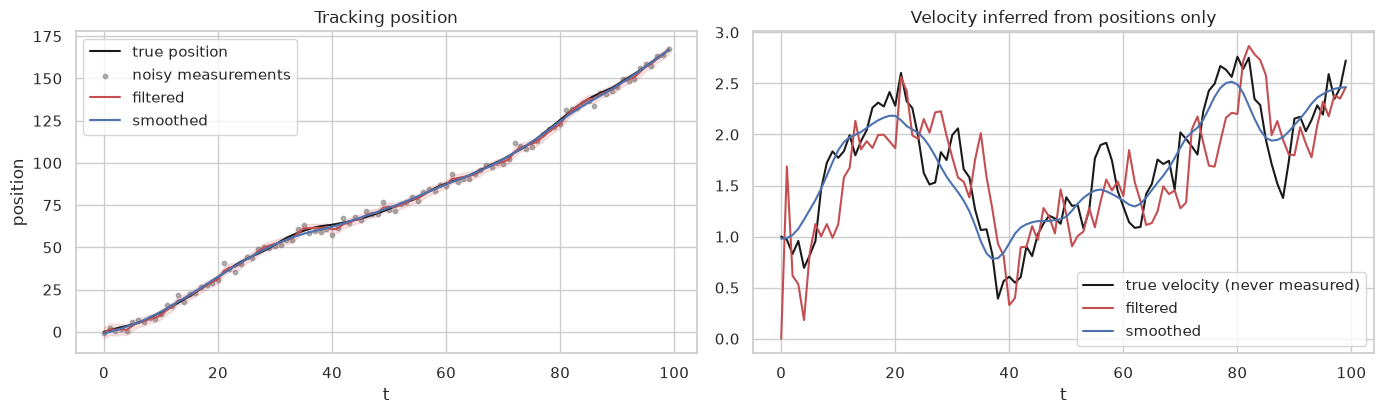

In [13]:
def kalman(x, F, H, Q, R, m0, P0):
    T, d = len(x), len(m0); mf, Pf, mp, Pp = (np.zeros((T, d)), np.zeros((T, d, d)), np.zeros((T, d)), np.zeros((T, d, d)))
    m, P = m0, P0
    for t in range(T):
        mp[t], Pp[t] = (F @ m, F @ P @ F.T + Q) if t > 0 else (m0, P0)                    # predict
        S = H @ Pp[t] @ H.T + R; K = Pp[t] @ H.T @ np.linalg.inv(S)                       # Kalman gain
        m = mp[t] + K @ (x[t] - H @ mp[t]); P = (np.eye(d) - K @ H) @ Pp[t]; mf[t], Pf[t] = m, P   # update
    ms, Ps = mf.copy(), Pf.copy()                                                          # RTS smoother
    for t in range(T - 2, -1, -1):
        J = Pf[t] @ F.T @ np.linalg.inv(Pp[t + 1]); ms[t] = mf[t] + J @ (ms[t + 1] - mp[t + 1]); Ps[t] = Pf[t] + J @ (Ps[t + 1] - Pp[t + 1]) @ J.T
    return mf, Pf, ms, Ps

dt = 1.0; F = np.array([[1, dt], [0, 1]]); H = np.array([[1.0, 0.0]]); Q = 0.05 * np.array([[dt ** 3 / 3, dt ** 2 / 2], [dt ** 2 / 2, dt]]); R = np.array([[4.0]])
rng = np.random.default_rng(0); T = 100; z = np.zeros((T, 2)); z[0] = [0, 1]
for t in range(1, T): z[t] = F @ z[t - 1] + rng.multivariate_normal([0, 0], Q)
xobs = z[:, :1] + rng.normal(0, np.sqrt(R[0, 0]), (T, 1))
mf, Pf, ms, Ps = kalman(xobs, F, H, Q, R, np.array([0.0, 0.0]), np.eye(2) * 10)

rm = lambda e: np.sqrt(np.mean(e ** 2))
print(f"position RMSE: raw measurements {rm(xobs[:, 0] - z[:, 0]):.3f}   Kalman filter {rm(mf[:, 0] - z[:, 0]):.3f}   RTS smoother {rm(ms[:, 0] - z[:, 0]):.3f}")
fig, ax = plt.subplots(1, 2, figsize=(14, 4.3))
ax[0].plot(z[:, 0], "k", label="true position"); ax[0].scatter(range(T), xobs[:, 0], s=10, c="gray", alpha=.6, label="noisy measurements")
ax[0].plot(mf[:, 0], "r", label="filtered"); ax[0].plot(ms[:, 0], "b", label="smoothed"); sd = np.sqrt(Pf[:, 0, 0]); ax[0].fill_between(range(T), mf[:, 0] - 2 * sd, mf[:, 0] + 2 * sd, color="r", alpha=.15)
ax[0].legend(); ax[0].set(xlabel="t", ylabel="position", title="Tracking position")
ax[1].plot(z[:, 1], "k", label="true velocity (never measured)"); ax[1].plot(mf[:, 1], "r", label="filtered"); ax[1].plot(ms[:, 1], "b", label="smoothed"); ax[1].legend(); ax[1].set(xlabel="t", title="Velocity inferred from positions only")
plt.tight_layout(); plt.show()

## Summary
* Markov chains: ML transition estimates and stationary distributions.
* Implemented the **HMM from scratch**: scaled forward–backward (verified against brute-force enumeration), **Baum–Welch** (likelihood monotonically increases), **Viterbi** decoding, and next-step / multi-step prediction.
* Learned a discrete HMM from observations only, recovered the hidden weather, beat frequency and Markov-on-observation baselines for prediction, and chose the number of states with held-out likelihood/BIC.
* Applied a Gaussian-emission HMM to regime detection and volatility forecasting.
* Linear dynamical systems: Kalman filter and RTS smoother for tracking.